In [18]:
import pandas as pd
import numpy as np

In [115]:
df = pd.read_csv("/content/cleaned_mortality_dataset.csv")

print(df.shape)
df.head()

(38415, 19)


,location,survey_type,month,year,recall_period,HH,Cluster,Team,Total,Births,Joined,Left,Total_U5,Births_U5,Joined_U5,Left_U5,Person_Time,Person_Time_U5,Mortality
0,18,1,6,2018,96,2,16,2,6,0,0,0,2,0,0,0,576.0,192.0,0
1,18,1,6,2018,96,248,16,2,5,0,0,0,2,0,0,0,480.0,192.0,0
2,18,1,6,2018,96,503,16,2,2,0,0,0,0,0,0,0,192.0,0.0,0
3,18,1,6,2018,96,750,16,2,5,0,0,0,2,0,0,0,480.0,192.0,0
4,18,1,6,2018,96,997,16,2,8,0,0,0,1,0,0,0,768.0,96.0,0


In [20]:
print(df.isnull().sum())

location             0
survey_type          0
month             1971
year              1379
recall_period        0
HH                1398
Cluster           1379
Team              1397
Total                0
Births               0
Deaths               0
Joined               0
Left                 0
Total_U5             0
Births_U5            0
Deaths_U5            0
Joined_U5            0
Left_U5              0
Person_Time          0
Person_Time_U5       0
dtype: int64


In [21]:
print(df.shape)

(42538, 20)


In [22]:
df["month"] = df["month"].fillna(df["month"].mode()[0])
df["year"] = df["year"].fillna(df["year"].mode()[0])

In [23]:
df["HH"] = df["HH"].fillna("Unknown")
df["Cluster"] = df["Cluster"].fillna("Unknown")
df["Team"] = df["Team"].fillna("Unknown")

In [24]:
print(df.isnull().sum())

location          0
survey_type       0
month             0
year              0
recall_period     0
HH                0
Cluster           0
Team              0
Total             0
Births            0
Deaths            0
Joined            0
Left              0
Total_U5          0
Births_U5         0
Deaths_U5         0
Joined_U5         0
Left_U5           0
Person_Time       0
Person_Time_U5    0
dtype: int64


In [25]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1473


In [26]:
print(df[["Deaths", "Births", "Total", "Person_Time"]].describe())

             Deaths        Births         Total   Person_Time
count  42538.000000  42538.000000  42538.000000  42538.000000
mean       0.016385      0.067822      4.209624    408.919390
std        0.140323      0.274849      2.551433    252.340921
min        0.000000      0.000000      0.000000      0.000000
25%        0.000000      0.000000      2.000000    225.000000
50%        0.000000      0.000000      4.000000    392.000000
75%        0.000000      0.000000      6.000000    572.000000
max        5.000000      6.000000     31.000000   2790.000000


In [27]:
df["Mortality"] = (df["Deaths"] > 0).astype(int)

print(df["Mortality"].value_counts())
print(df["Mortality"].value_counts(normalize=True) * 100)

Mortality
0    41893
1      645
Name: count, dtype: int64
Mortality
0    98.483709
1     1.516291
Name: proportion, dtype: float64


In [28]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (41065, 21)


In [30]:
print("Total = 0:", (df["Total"] == 0).sum())
print("Person_Time = 0:", (df["Person_Time"] == 0).sum())

Total = 0: 2573
Person_Time = 0: 2637


In [31]:
df = df[df["Total"] > 0]
df = df[df["Person_Time"] > 0]

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38415 entries, 0 to 42537
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        38415 non-null  object 
 1   survey_type     38415 non-null  object 
 2   month           38415 non-null  float64
 3   year            38415 non-null  float64
 4   recall_period   38415 non-null  int64  
 5   HH              38415 non-null  object 
 6   Cluster         38415 non-null  object 
 7   Team            38415 non-null  object 
 8   Total           38415 non-null  int64  
 9   Births          38415 non-null  int64  
 10  Deaths          38415 non-null  int64  
 11  Joined          38415 non-null  int64  
 12  Left            38415 non-null  int64  
 13  Total_U5        38415 non-null  int64  
 14  Births_U5       38415 non-null  int64  
 15  Deaths_U5       38415 non-null  int64  
 16  Joined_U5       38415 non-null  int64  
 17  Left_U5         38415 non-null  int6

In [41]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "location",
    "survey_type",
    "Team"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [38]:
categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['HH', 'Cluster', 'Team'], dtype='object')


In [39]:
for col in categorical_columns:
    print("\nColumn:", col)
    print(df[col].apply(type).value_counts())


Column: HH
HH
<class 'str'>    38415
Name: count, dtype: int64

Column: Cluster
Cluster
<class 'str'>      29668
<class 'float'>     8747
Name: count, dtype: int64

Column: Team
Team
<class 'float'>    38409
<class 'str'>          6
Name: count, dtype: int64


In [40]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = df.select_dtypes(include=['object']).columns

encoder = LabelEncoder()

for col in categorical_columns:

    # Replace missing values
    df[col] = df[col].fillna("Unknown")

    # Convert all values to string
    df[col] = df[col].astype(str)

    # Encode
    df[col] = encoder.fit_transform(df[col])

print("Encoding completed successfully")

Encoding completed successfully


In [42]:
print(df["Mortality"].value_counts())
print(df["Mortality"].value_counts(normalize=True) * 100)

Mortality
0    37788
1      627
Name: count, dtype: int64
Mortality
0    98.367825
1     1.632175
Name: proportion, dtype: float64


In [99]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop("Mortality", axis=1)

# Target
y = df["Mortality"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (30732, 20)
Testing samples: (7683, 20)


In [116]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop("Mortality", axis=1)

# Target
y = df["Mortality"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (30732, 18)
Testing samples: (7683, 18)


In [117]:
!pip install imbalanced-learn

In [118]:
from imblearn.over_sampling import SMOTE

In [119]:
print("Before SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

Before SMOTE:
Mortality
0    30230
1      502
Name: count, dtype: int64
Mortality
0    98.366523
1     1.633477
Name: proportion, dtype: float64


In [120]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

In [121]:
print("After SMOTE:")
print(y_train_balanced.value_counts())
print(y_train_balanced.value_counts(normalize=True) * 100)

After SMOTE:
Mortality
0    30230
1    30230
Name: count, dtype: int64
Mortality
0    50.0
1    50.0
Name: proportion, dtype: float64


In [122]:
import pandas as pd

balanced_train = pd.concat(
    [
        pd.DataFrame(X_train_balanced, columns=X.columns),
        pd.DataFrame(y_train_balanced, columns=["Mortality"])
    ],
    axis=1
)

balanced_train.to_csv("balanced_training_dataset.csv", index=False)

print("Balanced training dataset saved successfully.")

Balanced training dataset saved successfully.


In [123]:
print(X.columns.tolist())

['location', 'survey_type', 'month', 'year', 'recall_period', 'HH', 'Cluster', 'Team', 'Total', 'Births', 'Joined', 'Left', 'Total_U5', 'Births_U5', 'Joined_U5', 'Left_U5', 'Person_Time', 'Person_Time_U5']


In [124]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [125]:
rf_model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(random_state=42)

In [126]:
y_pred_rf = rf_model.predict(X_test)

In [127]:
y_pred_rf = rf_model.predict(X_test)

In [128]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Random Forest Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
----------------------------------------
Accuracy : 0.9890667707926591
Precision: 0.9555555555555556
Recall   : 0.344
F1 Score : 0.5058823529411764

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7558
           1       0.96      0.34      0.51       125

    accuracy                           0.99      7683
   macro avg       0.97      0.67      0.75      7683
weighted avg       0.99      0.99      0.99      7683


Confusion Matrix
[[7556    2]
 [  82   43]]


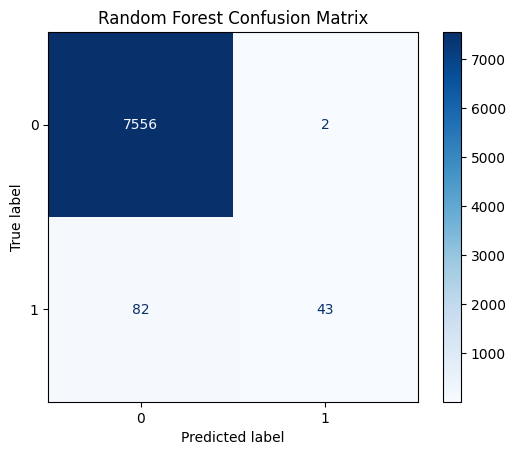

In [129]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [130]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
16     Person_Time    0.146283
17  Person_Time_U5    0.141792
3             year    0.108773
4    recall_period    0.104285
2            month    0.092871
7             Team    0.070697
8            Total    0.069573
0         location    0.062627
12        Total_U5    0.054692
5               HH    0.041076
1      survey_type    0.032867
6          Cluster    0.032373
9           Births    0.019888
11            Left    0.010898
13       Births_U5    0.006615
10          Joined    0.002155
15         Left_U5    0.002020
14       Joined_U5    0.000517


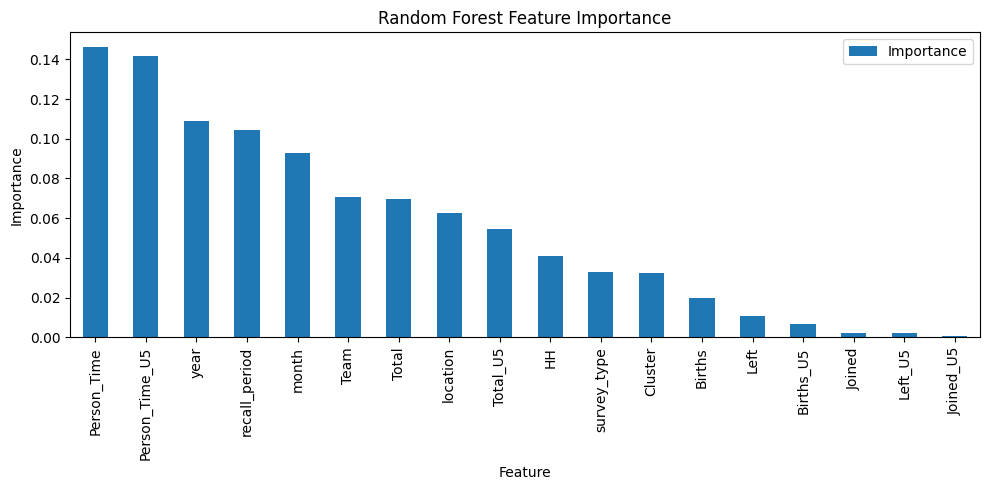

In [131]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [132]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9375332098438741


In [133]:
import joblib

joblib.dump(rf_model, "random_forest_mortality_model.pkl")

['random_forest_mortality_model.pkl']

In [134]:
from sklearn.linear_model import LogisticRegression

In [135]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [136]:
lr_model.fit(X_train_balanced, y_train_balanced)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [137]:
y_pred_lr = lr_model.predict(X_test)

In [138]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
----------------------------------------
Accuracy : 0.9833398412078616
Precision: 0.4933920704845815
Recall   : 0.896
F1 Score : 0.6363636363636364

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      7558
           1       0.49      0.90      0.64       125

    accuracy                           0.98      7683
   macro avg       0.75      0.94      0.81      7683
weighted avg       0.99      0.98      0.99      7683


Confusion Matrix
[[7443  115]
 [  13  112]]


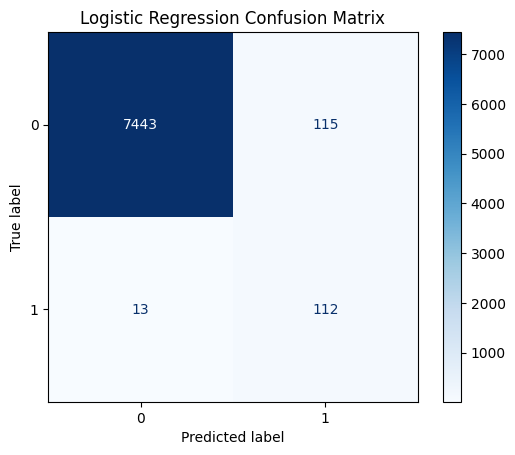

In [139]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [140]:
from sklearn.metrics import roc_auc_score

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9584016935697274


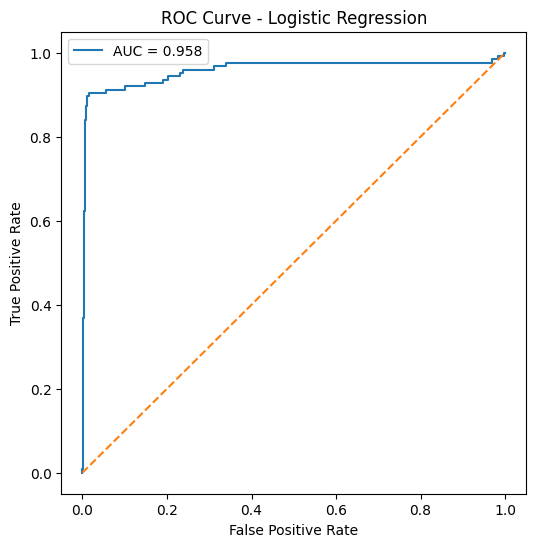

In [141]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [142]:
import joblib

joblib.dump(lr_model, "logistic_regression_mortality_model.pkl")

['logistic_regression_mortality_model.pkl']

In [143]:
lr_model = joblib.load("logistic_regression_mortality_model.pkl")

In [144]:
from sklearn.naive_bayes import GaussianNB

In [145]:
nb_model = GaussianNB()

In [146]:
nb_model.fit(X_train_balanced, y_train_balanced)

GaussianNB()

In [147]:
y_pred_nb = nb_model.predict(X_test)

In [148]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Naive Bayes Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Results
----------------------------------------
Accuracy : 0.35598073669139657
Precision: 0.018758730792257036
Recall   : 0.752
F1 Score : 0.03660436137071651

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.35      0.52      7558
           1       0.02      0.75      0.04       125

    accuracy                           0.36      7683
   macro avg       0.50      0.55      0.28      7683
weighted avg       0.97      0.36      0.51      7683


Confusion Matrix
[[2641 4917]
 [  31   94]]


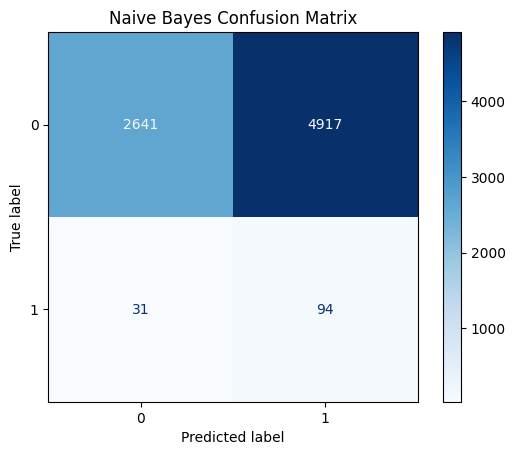

In [149]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [150]:
from sklearn.metrics import roc_auc_score

y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob_nb)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.5675226250330774


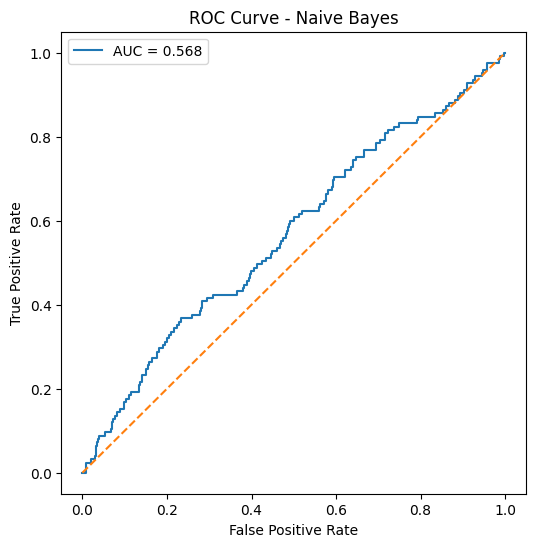

In [151]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()

plt.show()

In [152]:
import joblib

joblib.dump(nb_model, "naive_bayes_mortality_model.pkl")

['naive_bayes_mortality_model.pkl']

In [153]:
nb_model = joblib.load("naive_bayes_mortality_model.pkl")

In [154]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_nb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_nb)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_nb)
    ]
})

# Round values to 4 decimal places
comparison = comparison.round(4)

print("\nFinal Model Comparison")
print(comparison)


Final Model Comparison
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.9833     0.4934   0.896    0.6364   0.9584
1        Random Forest    0.9891     0.9556   0.344    0.5059   0.9375
2          Naive Bayes    0.3560     0.0188   0.752    0.0366   0.5675


In [155]:
comparison.set_index("Model", inplace=True)

print("\n================ FINAL MODEL COMPARISON ================\n")
print(comparison)


================ FINAL MODEL COMPARISON ================

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9833     0.4934   0.896    0.6364   0.9584
Random Forest          0.9891     0.9556   0.344    0.5059   0.9375
Naive Bayes            0.3560     0.0188   0.752    0.0366   0.5675


In [156]:
df.to_csv("cleaned_mortality_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [157]:
import pandas as pd

balanced_dataset = pd.concat(
    [
        pd.DataFrame(X_train_balanced, columns=X.columns),
        pd.DataFrame(y_train_balanced, columns=["Mortality"])
    ],
    axis=1
)

balanced_dataset.to_csv(
    "balanced_mortality_dataset.csv",
    index=False
)

print("Balanced dataset saved successfully!")

Balanced dataset saved successfully!


LOGISTIC REGRESSION RESULTS
Accuracy : 0.9833398412078616
Precision: 0.4933920704845815
Recall   : 0.896
F1 Score : 0.6363636363636364
ROC-AUC  : 0.9584016935697274

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      7558
           1       0.49      0.90      0.64       125

    accuracy                           0.98      7683
   macro avg       0.75      0.94      0.81      7683
weighted avg       0.99      0.98      0.99      7683


Confusion Matrix
[[7443  115]
 [  13  112]]


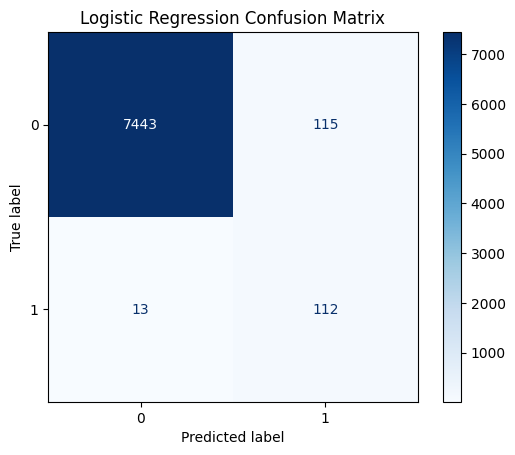

RANDOM FOREST RESULTS
Accuracy : 0.9890667707926591
Precision: 0.9555555555555556
Recall   : 0.344
F1 Score : 0.5058823529411764
ROC-AUC  : 0.9375332098438741

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7558
           1       0.96      0.34      0.51       125

    accuracy                           0.99      7683
   macro avg       0.97      0.67      0.75      7683
weighted avg       0.99      0.99      0.99      7683


Confusion Matrix
[[7556    2]
 [  82   43]]


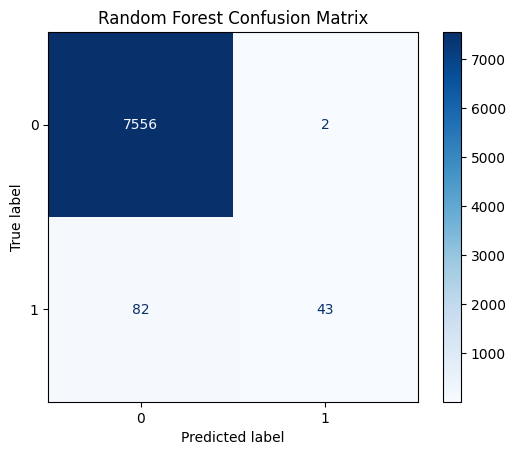

NAIVE BAYES RESULTS
Accuracy : 0.35598073669139657
Precision: 0.018758730792257036
Recall   : 0.752
F1 Score : 0.03660436137071651
ROC-AUC  : 0.5675226250330774

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.35      0.52      7558
           1       0.02      0.75      0.04       125

    accuracy                           0.36      7683
   macro avg       0.50      0.55      0.28      7683
weighted avg       0.97      0.36      0.51      7683


Confusion Matrix
[[2641 4917]
 [  31   94]]


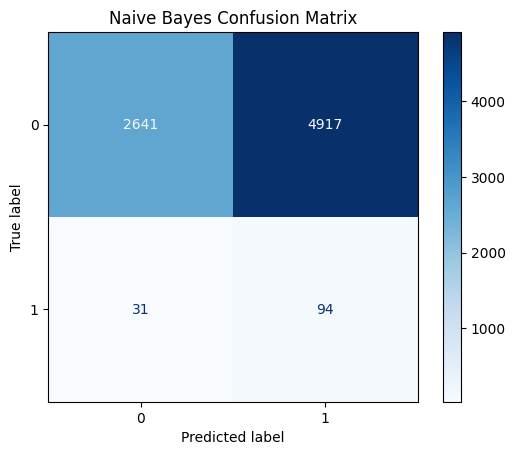



FINAL MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.9833     0.4934   0.896    0.6364   0.9584
1        Random Forest    0.9891     0.9556   0.344    0.5059   0.9375
2          Naive Bayes    0.3560     0.0188   0.752    0.0366   0.5675

Comparison table saved as model_comparison_results.csv


In [158]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ==========================================
# Logistic Regression
# ==========================================

print("="*70)
print("LOGISTIC REGRESSION RESULTS")
print("="*70)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# ==========================================
# Random Forest
# ==========================================

print("="*70)
print("RANDOM FOREST RESULTS")
print("="*70)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ==========================================
# Naive Bayes
# ==========================================

print("="*70)
print("NAIVE BAYES RESULTS")
print("="*70)

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_nb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_nb))

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test,
    y_test,
    cmap="Blues"
)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

# ==========================================
# FINAL COMPARISON TABLE
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_nb)
    ]
})

comparison = comparison.round(4)

print("\n")
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(comparison)

comparison.to_csv("model_comparison_results.csv", index=False)

print("\nComparison table saved as model_comparison_results.csv")

In [91]:
print(X.columns.tolist())

['location', 'survey_type', 'month', 'year', 'recall_period', 'HH', 'Cluster', 'Team', 'Total', 'Births', 'Deaths', 'Joined', 'Left', 'Total_U5', 'Births_U5', 'Deaths_U5', 'Joined_U5', 'Left_U5', 'Person_Time', 'Person_Time_U5']


In [98]:
X = df.drop(columns=[
    "Mortality",
    "Deaths",
    "Deaths_U5"
])

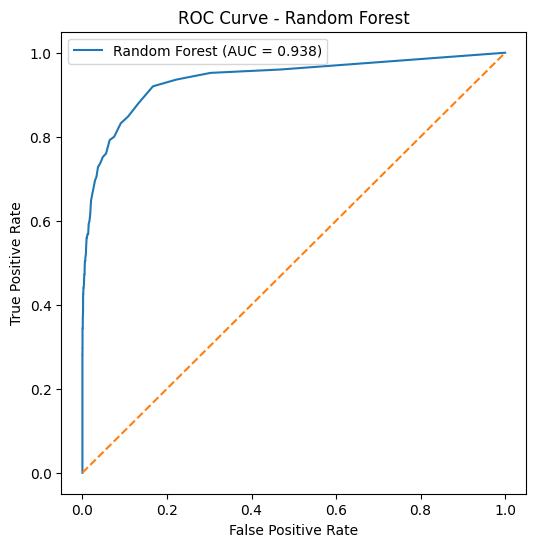

In [159]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions for Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

# Calculate AUC
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC Curve
plt.figure(figsize=(6,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# Random guessing line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()